In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
from pathlib import Path
import matplotlib.pyplot as plt
import pickle

tf.random.set_seed(42)
np.random.seed(42)

print('TF:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

TF: 2.15.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('../..').resolve()
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))
from paths import DATA_RAW_DIR, DATA_PROCESSED_DIR, EXPERIMENTS_DIR, EMBEDDINGS_DIR

DATA_DIR = DATA_RAW_DIR
IMG_DIR = DATA_DIR / 'images'
STYLES_CSV = DATA_DIR / 'styles.csv'
PROC_DIR = DATA_PROCESSED_DIR
CKPT_DIR = EXPERIMENTS_DIR
EMB_DIR = EMBEDDINGS_DIR
CKPT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE       = 224
EMBED_DIM      = 256
TEXT_MAX_LEN   = 32
VOCAB_SIZE     = 10000
BATCH_SIZE     = 64
TEMPERATURE    = 0.07

# Reduced from 5 -> 3 because the model overfits past epoch 3 on the full dataset.
# Early stopping (with restore_best_weights) keeps the lowest-val_loss weights
# regardless, so this is also a safety net.
BASELINE_EPOCHS = 3
BASELINE_LR     = 1e-3

FT_EPOCHS       = 3
FT_LR           = 1e-5
UNFREEZE_FROM   = -20

def make_early_stopping(patience=1):
    return tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True,
        verbose=1,
    )

In [3]:
train_df = pd.read_csv(PROC_DIR / 'train.csv').reset_index(drop=True)
val_df   = pd.read_csv(PROC_DIR / 'val.csv').reset_index(drop=True)
test_df  = pd.read_csv(PROC_DIR / 'test.csv').reset_index(drop=True)

print(f'Train: {len(train_df):,}')
print(f'Val:   {len(val_df):,}')
print(f'Test:  {len(test_df):,}')

Train: 35,412
Val:   4,426
Test:  4,427


In [4]:
vectorizer = layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=TEXT_MAX_LEN,
    standardize='lower_and_strip_punctuation',
)
vectorizer.adapt(train_df['caption'].values)
print('Vocab size:', len(vectorizer.get_vocabulary()))

2026-04-30 20:09:27.338450: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-04-30 20:09:27.338471: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-04-30 20:09:27.338482: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.00 GB
2026-04-30 20:09:27.338728: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-30 20:09:27.339081: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-04-30 20:09:27.448562: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Vocab size: 7980


In [5]:
def load_image(path):
    raw = tf.io.read_file(path)
    img = tf.io.decode_jpeg(raw, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    return tf.cast(img, tf.float32)

def make_dataset(df, training=False):
    paths    = (str(IMG_DIR.resolve()) + '/' + df['image_path']).values
    captions = df['caption'].values
    ds = tf.data.Dataset.from_tensor_slices((paths, captions))
    if training:
        ds = ds.shuffle(4096, reshuffle_each_iteration=True)
    ds = ds.map(lambda p, c: (load_image(p), c), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE, drop_remainder=True)
    ds = ds.map(lambda i, c: (i, vectorizer(c)), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

class TransformerBlock(layers.Layer):
    def __init__(self, dim, heads=4, ff=256, dropout=0.1):
        super().__init__()
        self.attn = layers.MultiHeadAttention(num_heads=heads, key_dim=dim // heads)
        self.ffn  = tf.keras.Sequential([
            layers.Dense(ff, activation='relu'),
            layers.Dense(dim),
        ])
        self.ln1 = layers.LayerNormalization()
        self.ln2 = layers.LayerNormalization()
        self.dropout = layers.Dropout(dropout)

    def call(self, x, training=False):
        a = self.attn(x, x, x)
        x = self.ln1(x + self.dropout(a, training=training))
        f = self.ffn(x)
        x = self.ln2(x + self.dropout(f, training=training))
        return x

def build_image_encoder():
    base = tf.keras.applications.EfficientNetB0(
        include_top=False, pooling='avg', weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    base.trainable = False
    inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x   = base(inp, training=False)
    x   = layers.Dense(512, activation='relu')(x)
    x   = layers.Dropout(0.1)(x)
    out = layers.Dense(EMBED_DIM)(x)
    return Model(inp, out, name='image_encoder'), base

def build_text_encoder(dim=128):
    inp = layers.Input(shape=(TEXT_MAX_LEN,), dtype='int64')
    tok = layers.Embedding(VOCAB_SIZE, dim, mask_zero=True)(inp)
    pos = layers.Embedding(TEXT_MAX_LEN, dim)(tf.range(TEXT_MAX_LEN))
    x   = tok + pos
    x   = TransformerBlock(dim, heads=4, ff=256)(x)
    x   = TransformerBlock(dim, heads=4, ff=256)(x)
    x   = layers.GlobalAveragePooling1D()(x)
    x   = layers.Dense(256, activation='relu')(x)
    out = layers.Dense(EMBED_DIM)(x)
    return Model(inp, out, name='text_encoder')

class DualEncoder(Model):
    def __init__(self, img_enc, txt_enc, temperature=TEMPERATURE):
        super().__init__()
        self.img_enc = img_enc
        self.txt_enc = txt_enc
        self.temperature = temperature
        self.loss_tracker = tf.keras.metrics.Mean(name='loss')

    @property
    def metrics(self):
        return [self.loss_tracker]

    def call(self, inputs, training=False):
        imgs, txts = inputs
        ie = tf.math.l2_normalize(self.img_enc(imgs, training=training), axis=-1)
        te = tf.math.l2_normalize(self.txt_enc(txts, training=training), axis=-1)
        return ie, te

    def contrastive_loss(self, ie, te):
        logits = tf.matmul(ie, te, transpose_b=True) / self.temperature
        labels = tf.range(tf.shape(logits)[0])
        loss_i = tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)
        loss_t = tf.keras.losses.sparse_categorical_crossentropy(labels, tf.transpose(logits), from_logits=True)
        return tf.reduce_mean((loss_i + loss_t) / 2.0)

    def train_step(self, data):
        imgs, txts = data
        with tf.GradientTape() as tape:
            ie, te = self((imgs, txts), training=True)
            loss = self.contrastive_loss(ie, te)
        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        self.loss_tracker.update_state(loss)
        return {'loss': self.loss_tracker.result()}

    def test_step(self, data):
        imgs, txts = data
        ie, te = self((imgs, txts), training=False)
        loss = self.contrastive_loss(ie, te)
        self.loss_tracker.update_state(loss)
        return {'loss': self.loss_tracker.result()}

def encode_dataset(df, image_encoder, text_encoder, batch_size=64):
    paths    = (str(IMG_DIR.resolve()) + '/' + df['image_path']).values
    captions = df['caption'].values
    ds = tf.data.Dataset.from_tensor_slices((paths, captions))
    ds = ds.map(lambda p, c: (load_image(p), c), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    img_emb, txt_emb = [], []
    for imgs, txts in ds:
        ie = tf.math.l2_normalize(image_encoder(imgs, training=False), axis=-1)
        te = tf.math.l2_normalize(text_encoder(vectorizer(txts), training=False), axis=-1)
        img_emb.append(ie.numpy())
        txt_emb.append(te.numpy())
    return np.concatenate(img_emb), np.concatenate(txt_emb)

def recall_at_k(query_emb, gallery_emb, ks=(1, 5, 10)):
    sims = query_emb @ gallery_emb.T
    n = sims.shape[0]
    ranks = np.argsort(-sims, axis=1)
    correct = (ranks == np.arange(n)[:, None])
    return {f'R@{k}': float(correct[:, :k].any(axis=1).mean()) for k in ks}

In [6]:
image_encoder, effnet = build_image_encoder()
text_encoder = build_text_encoder()

model = DualEncoder(image_encoder, text_encoder)
model.compile(optimizer=tf.keras.optimizers.legacy.Adam(BASELINE_LR))

train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df,   training=False)

baseline_hist = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=BASELINE_EPOCHS,
    callbacks=[make_early_stopping(patience=1)],
)

Epoch 1/3
553/553 [==============================] - 144s 254ms/step - loss: 1.2286 - val_loss: 0.7530
Epoch 2/3
553/553 [==============================] - 132s 239ms/step - loss: 0.6433 - val_loss: 0.6248
Epoch 3/3
553/553 [==============================] - 133s 240ms/step - loss: 0.4981 - val_loss: 0.5882


In [7]:
img_emb_base, txt_emb_base = encode_dataset(val_df, image_encoder, text_encoder)
baseline_t2i = recall_at_k(txt_emb_base, img_emb_base)
baseline_i2t = recall_at_k(img_emb_base, txt_emb_base)

print('Gallery size:', len(img_emb_base))
print('Baseline Text -> Image:', baseline_t2i)
print('Baseline Image -> Text:', baseline_i2t)

image_encoder.save_weights(CKPT_DIR / 'final_image_encoder_baseline.weights.h5')
text_encoder.save_weights(CKPT_DIR / 'final_text_encoder_baseline.weights.h5')

Gallery size: 4426
Baseline Text -> Image: {'R@1': 0.07953004970628107, 'R@5': 0.2711251694532309, 'R@10': 0.4200180750112969}
Baseline Image -> Text: {'R@1': 0.08472661545413467, 'R@5': 0.29349299593312245, 'R@10': 0.43651152281970174}


In [8]:
effnet.trainable = True
n_layers = len(effnet.layers)
for i, layer in enumerate(effnet.layers):
    if i < n_layers + UNFREEZE_FROM:
        layer.trainable = False
    elif isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# Re-compile so trainable changes take effect
model = DualEncoder(image_encoder, text_encoder)
model.compile(optimizer=tf.keras.optimizers.legacy.Adam(FT_LR))

ft_hist = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FT_EPOCHS,
    callbacks=[make_early_stopping(patience=1)],
)

Epoch 1/3
553/553 [==============================] - 148s 261ms/step - loss: 0.3701 - val_loss: 0.5044
Epoch 2/3
553/553 [==============================] - 145s 261ms/step - loss: 0.3431 - val_loss: 0.4895
Epoch 3/3
553/553 [==============================] - 136s 245ms/step - loss: 0.3286 - val_loss: 0.4797


In [9]:
img_emb_ft, txt_emb_ft = encode_dataset(val_df, image_encoder, text_encoder)
ft_t2i = recall_at_k(txt_emb_ft, img_emb_ft)
ft_i2t = recall_at_k(img_emb_ft, txt_emb_ft)

print('Fine-tuned Text -> Image:', ft_t2i)
print('Fine-tuned Image -> Text:', ft_i2t)

image_encoder.save_weights(CKPT_DIR / 'final_image_encoder_ft.weights.h5')
text_encoder.save_weights(CKPT_DIR / 'final_text_encoder_ft.weights.h5')
with open(CKPT_DIR / 'final_vectorizer_vocab.pkl', 'wb') as f:
    pickle.dump(vectorizer.get_vocabulary(), f)

Fine-tuned Text -> Image: {'R@1': 0.10551287844554903, 'R@5': 0.33167645729778583, 'R@10': 0.48847718029823767}
Fine-tuned Image -> Text: {'R@1': 0.1034794396746498, 'R@5': 0.3380027112516945, 'R@10': 0.49073655671034794}


In [10]:
rows = []
for direction, base, ft in [('Text -> Image', baseline_t2i, ft_t2i),
                            ('Image -> Text', baseline_i2t, ft_i2t)]:
    for k in (1, 5, 10):
        rows.append({
            'Direction': direction,
            'Metric':    f'R@{k}',
            'Baseline':  f"{base[f'R@{k}']:.3f}",
            'Fine-tuned':f"{ft[f'R@{k}']:.3f}",
            'Δ (pp)':    f"{(ft[f'R@{k}'] - base[f'R@{k}'])*100:+.1f}",
        })
comparison = pd.DataFrame(rows)
print(comparison.to_string(index=False))
comparison.to_csv(CKPT_DIR / 'final_baseline_vs_finetuned.csv', index=False)

    Direction Metric Baseline Fine-tuned Δ (pp)
Text -> Image    R@1    0.080      0.106   +2.6
Text -> Image    R@5    0.271      0.332   +6.1
Text -> Image   R@10    0.420      0.488   +6.8
Image -> Text    R@1    0.085      0.103   +1.9
Image -> Text    R@5    0.293      0.338   +4.5
Image -> Text   R@10    0.437      0.491   +5.4


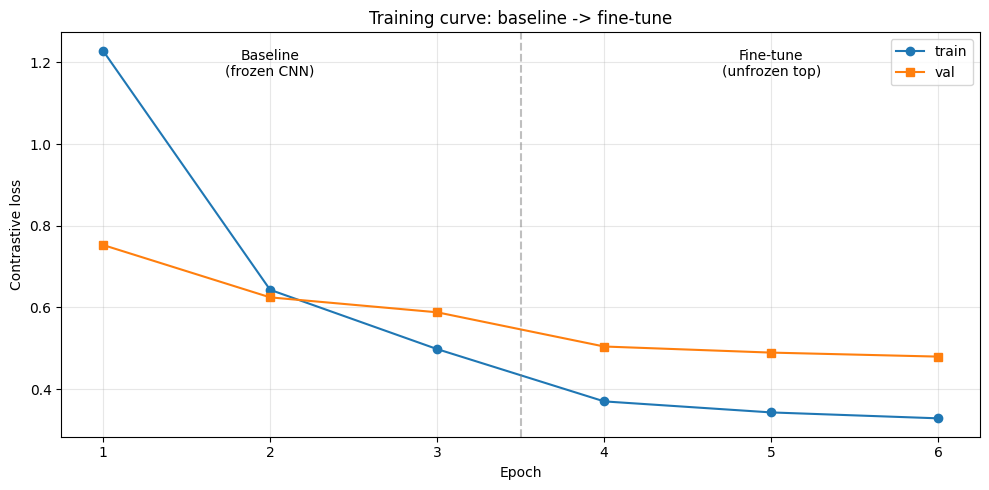

In [11]:
# Combined loss curves
all_train = baseline_hist.history['loss'] + ft_hist.history['loss']
all_val   = baseline_hist.history['val_loss'] + ft_hist.history['val_loss']
phase_change = len(baseline_hist.history['loss'])

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(all_train) + 1), all_train, marker='o', label='train')
plt.plot(range(1, len(all_val) + 1), all_val, marker='s', label='val')
plt.axvline(phase_change + 0.5, color='gray', linestyle='--', alpha=0.5)
plt.text(phase_change/2 + 0.5, max(all_train) * 0.95, 'Baseline\n(frozen CNN)', ha='center')
plt.text(phase_change + (len(all_train) - phase_change)/2 + 0.5, max(all_train) * 0.95, 'Fine-tune\n(unfrozen top)', ha='center')
plt.xlabel('Epoch'); plt.ylabel('Contrastive loss'); plt.legend(); plt.grid(True, alpha=0.3)
plt.title('Training curve: baseline -> fine-tune')
plt.tight_layout()
plt.savefig(CKPT_DIR / 'final_loss_curve.png', dpi=120)
plt.show()

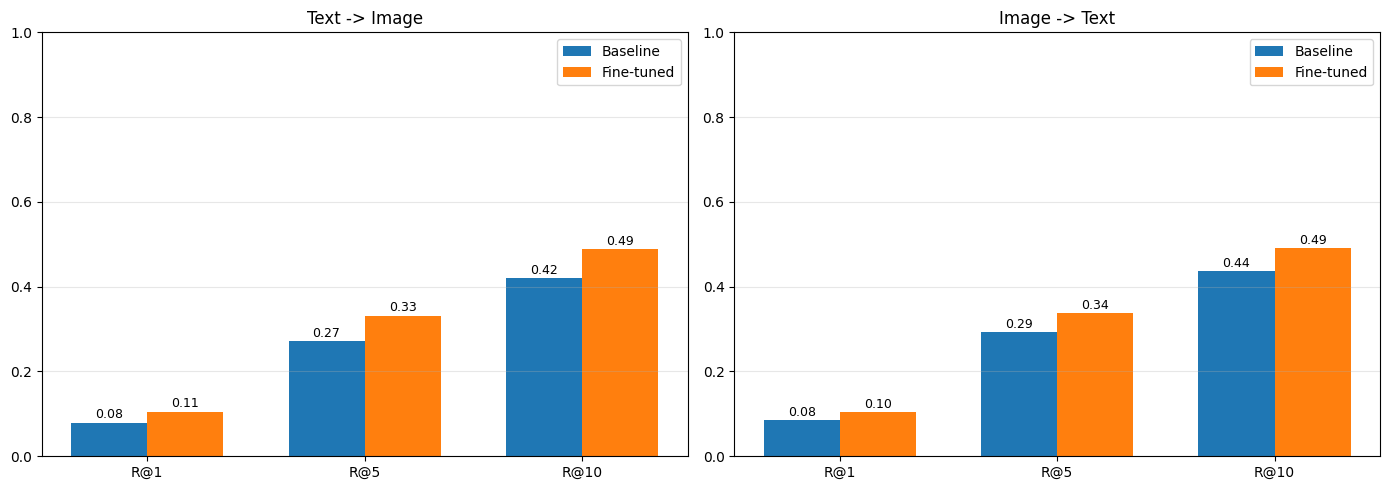

In [12]:
# Bar chart for the report
ks = ['R@1', 'R@5', 'R@10']
x = np.arange(len(ks))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, title, base, ft in [
    (axes[0], 'Text -> Image', baseline_t2i, ft_t2i),
    (axes[1], 'Image -> Text', baseline_i2t, ft_i2t),
]:
    base_vals = [base[k] for k in ks]
    ft_vals   = [ft[k]   for k in ks]
    ax.bar(x - w/2, base_vals, w, label='Baseline')
    ax.bar(x + w/2, ft_vals,   w, label='Fine-tuned')
    for i, (b, f_) in enumerate(zip(base_vals, ft_vals)):
        ax.text(i - w/2, b + 0.01, f'{b:.2f}', ha='center', fontsize=9)
        ax.text(i + w/2, f_ + 0.01, f'{f_:.2f}', ha='center', fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(ks)
    ax.set_ylim(0, 1)
    ax.set_title(title); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(CKPT_DIR / 'final_recall_comparison.png', dpi=120)
plt.show()

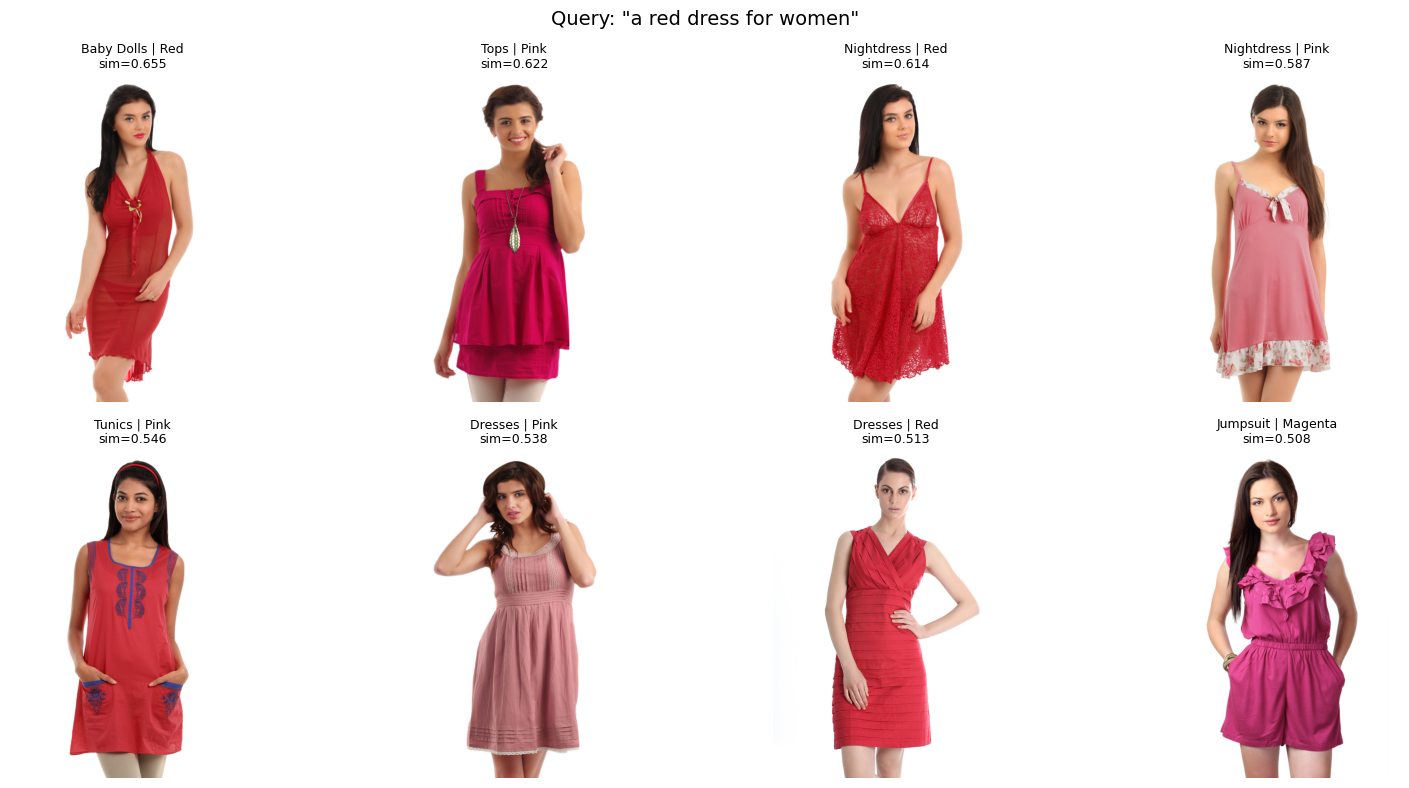

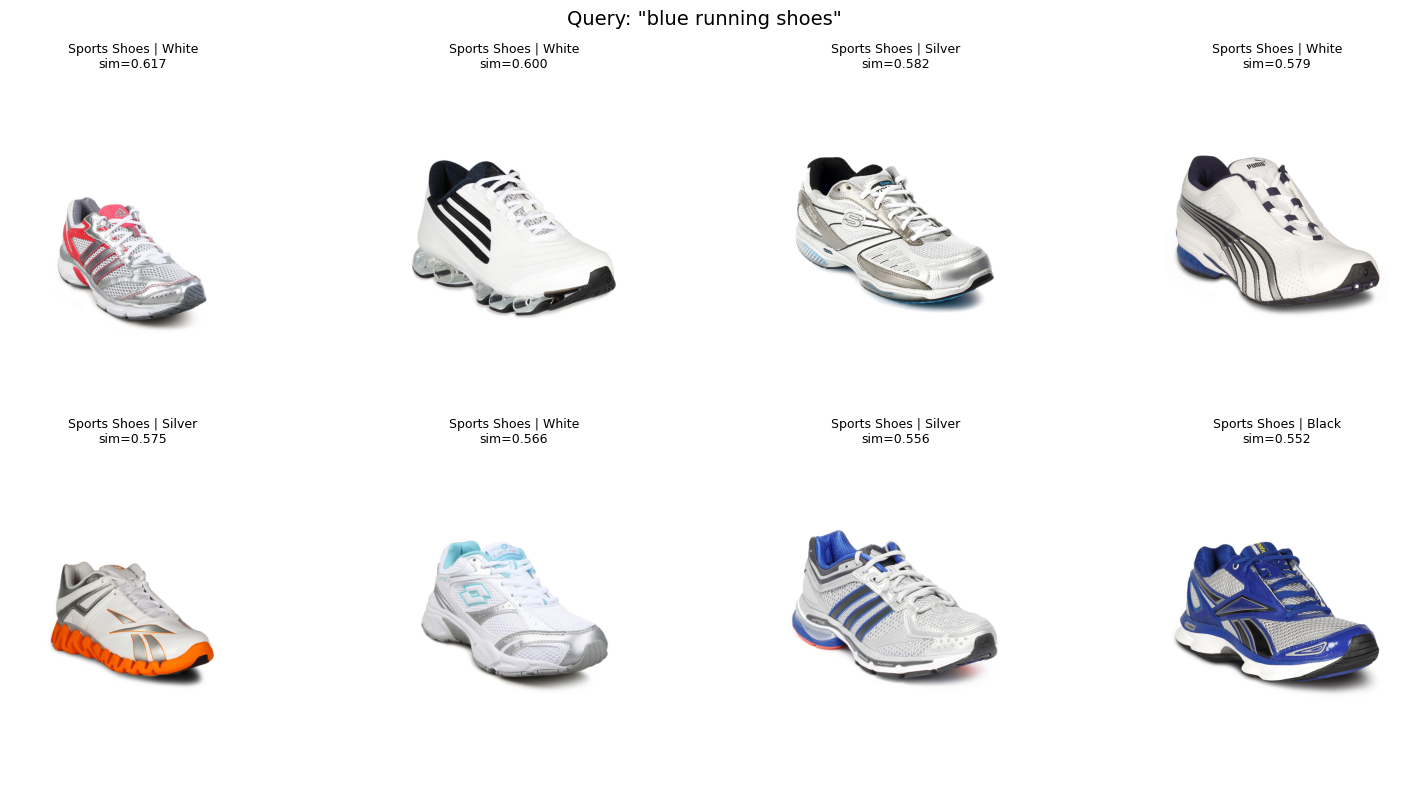

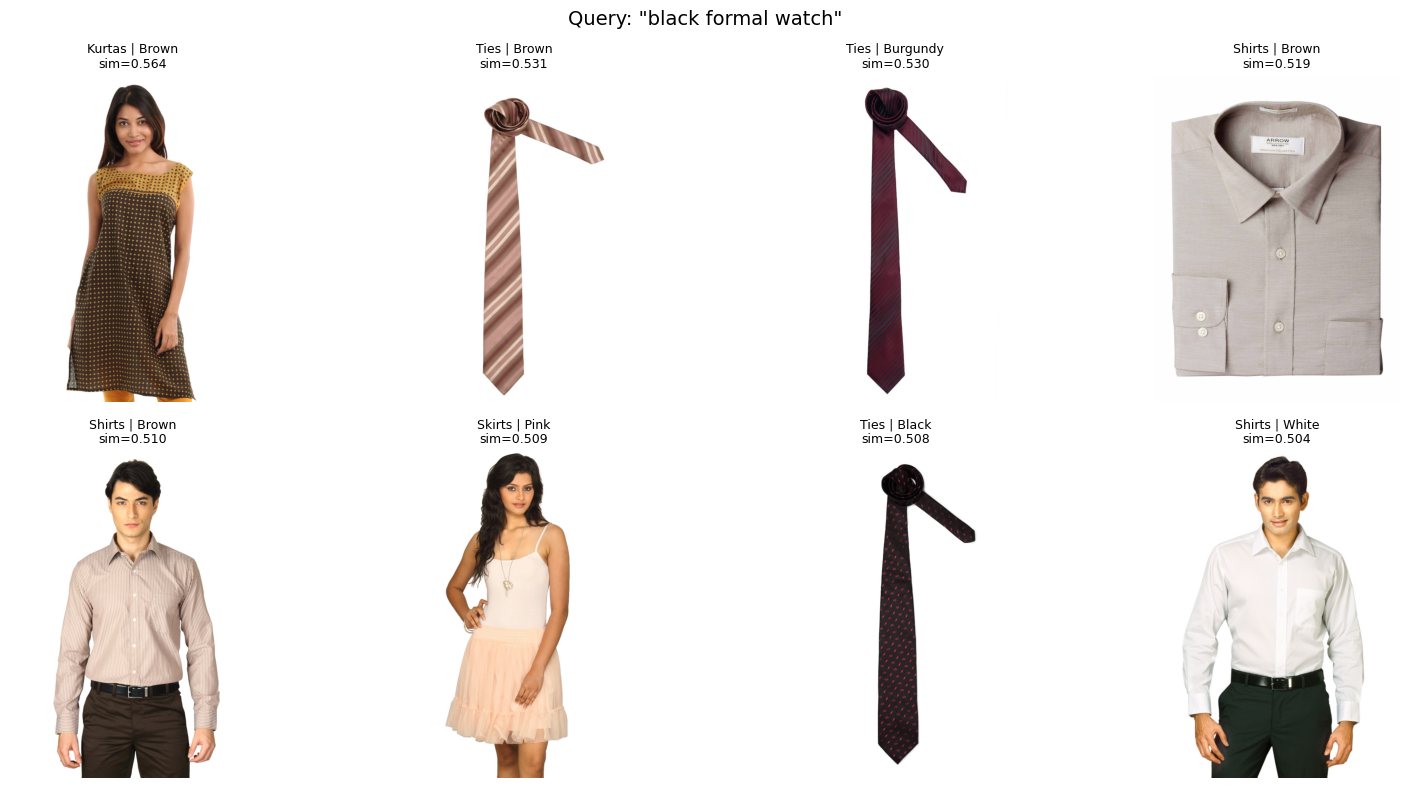

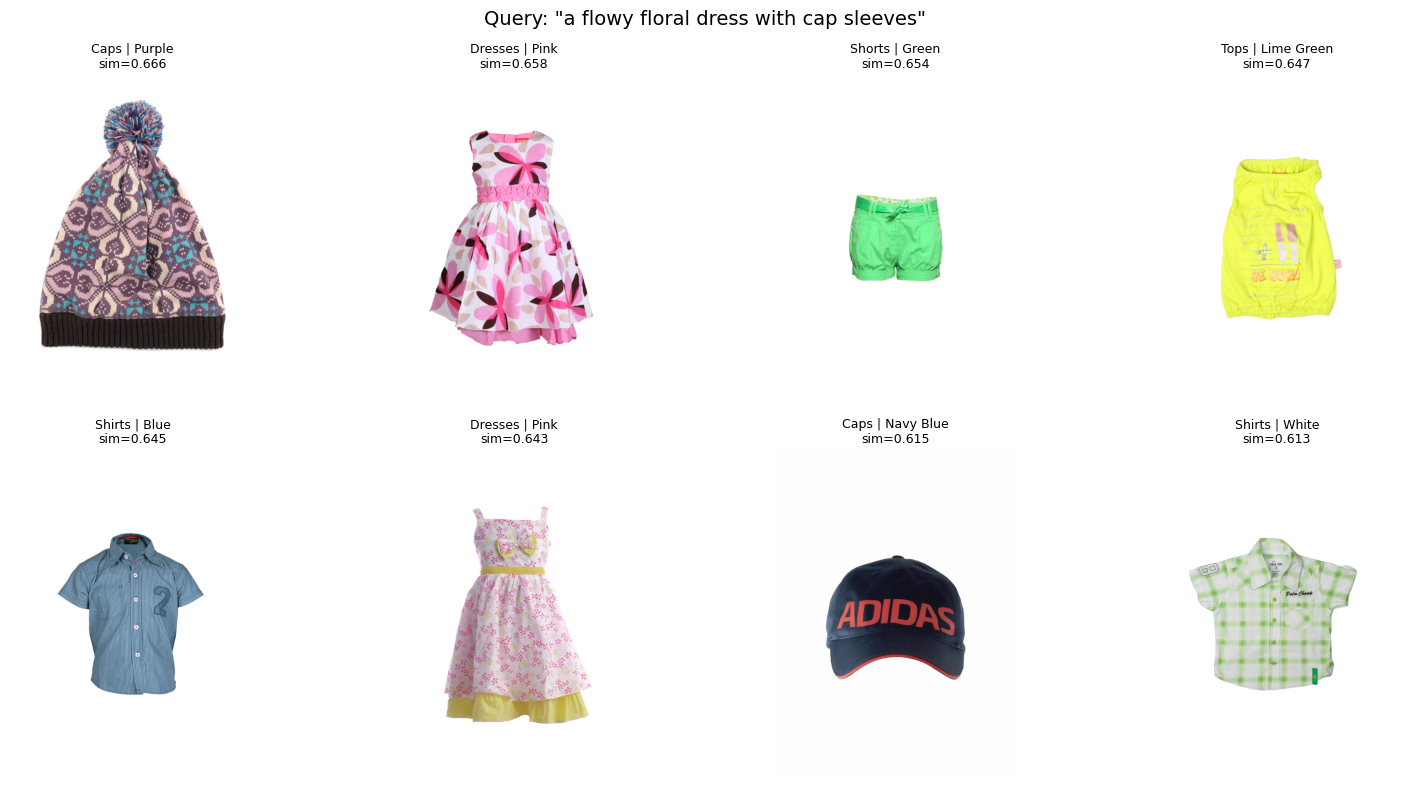

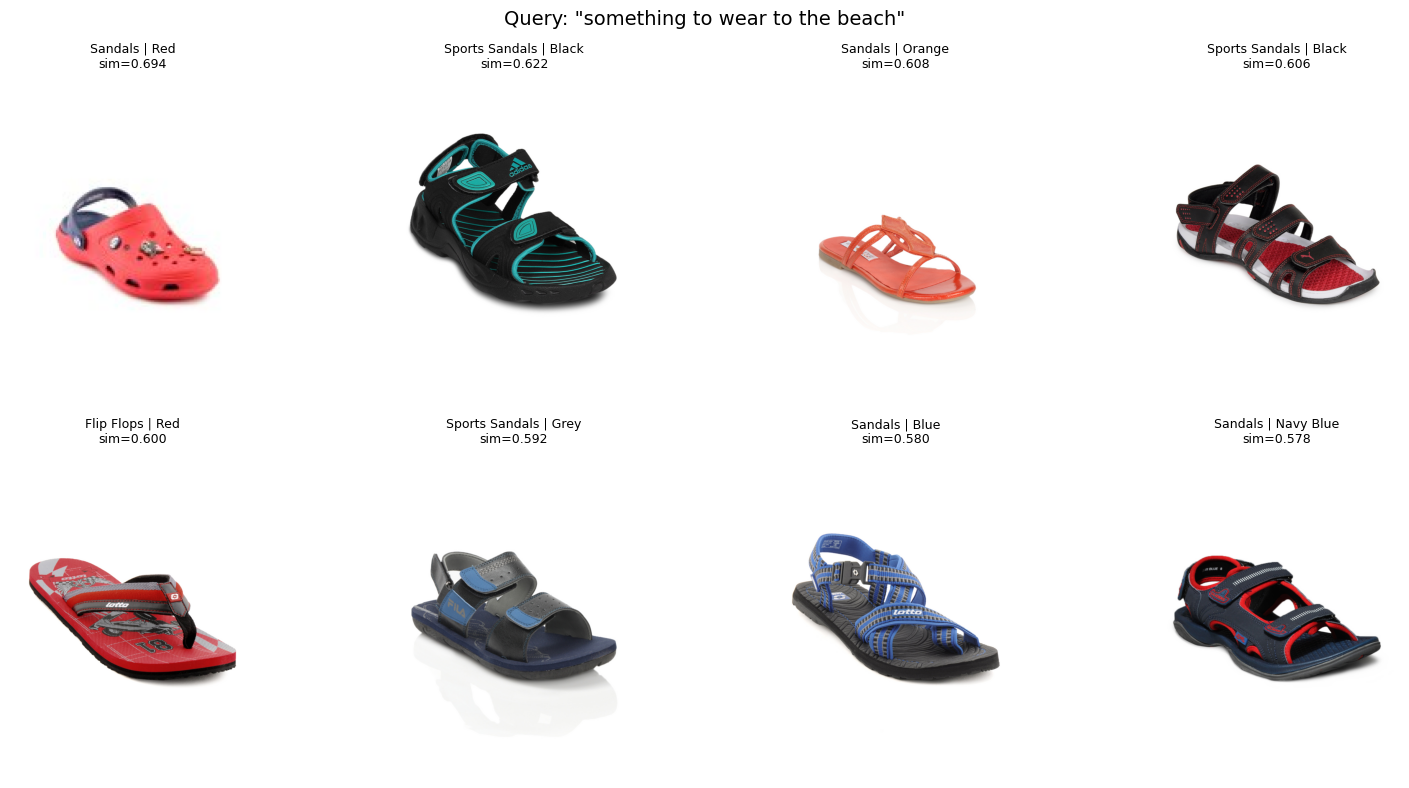

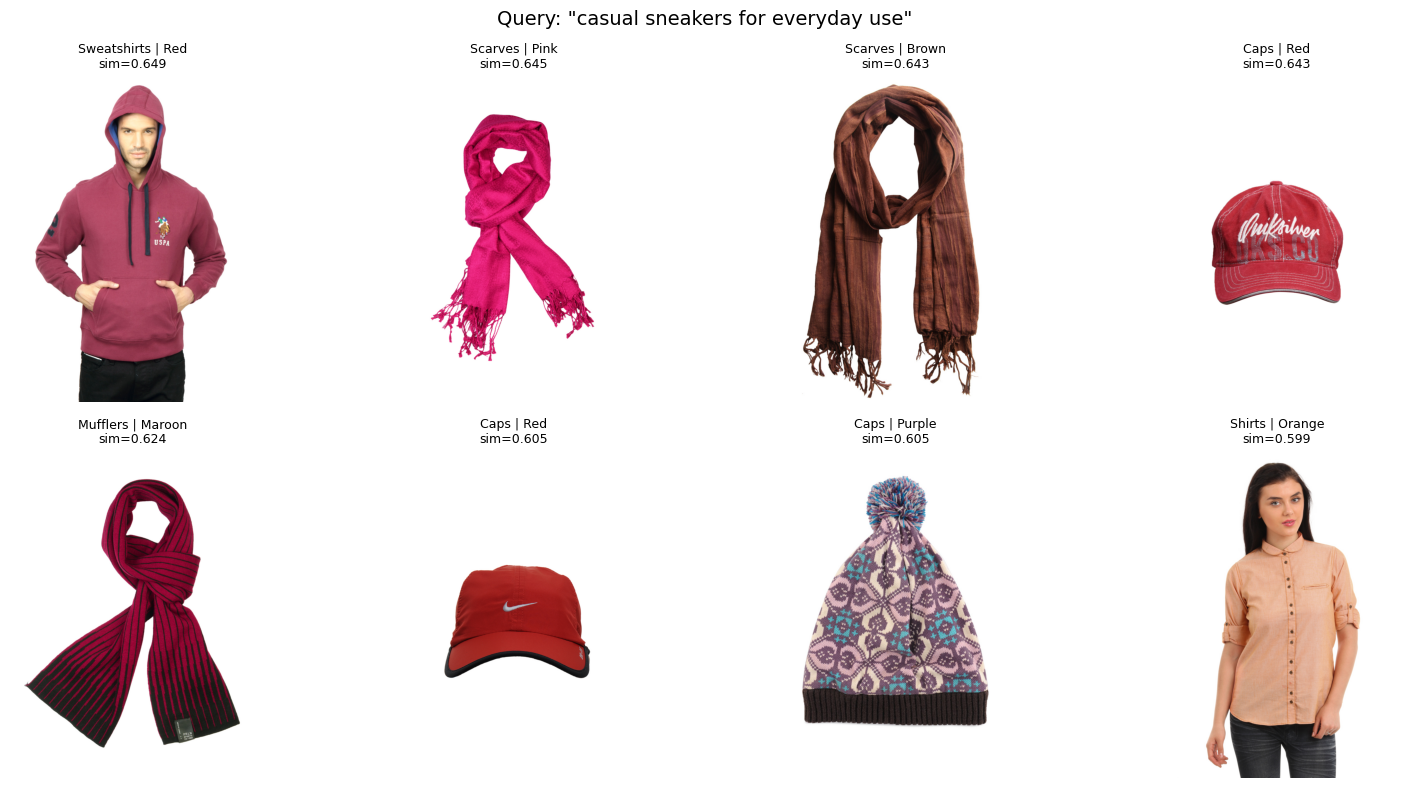

In [13]:
from PIL import Image

def search(query, df, gallery_emb, k=8):
    tokens = vectorizer([query])
    qe = tf.math.l2_normalize(text_encoder(tokens, training=False), axis=-1).numpy()
    sims = (qe @ gallery_emb.T).flatten()
    top = np.argsort(-sims)[:k]
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for ax, idx in zip(axes.flat, top):
        row = df.iloc[idx]
        img = Image.open(IMG_DIR / row['image_path'])
        ax.imshow(img)
        ax.set_title(f'{row["articleType"]} | {row["baseColour"]}\nsim={sims[idx]:.3f}', fontsize=9)
        ax.axis('off')
    fig.suptitle(f'Query: "{query}"', fontsize=14)
    plt.tight_layout()
    plt.show()

# In-distribution queries (matches the caption template)
for q in ['a red dress for women',
          'blue running shoes',
          'black formal watch']:
    search(q, val_df, img_emb_ft)

# Out-of-distribution natural-language queries
for q in ['a flowy floral dress with cap sleeves',
          'something to wear to the beach',
          'casual sneakers for everyday use']:
    search(q, val_df, img_emb_ft)